# Script generating gLV plots and Bifurcation Diagrams

In [1]:
### Preamble inclusions ###
using Plots
using DataFrames
using DynamicalSystems
using ProgressMeter
using DifferentialEquations
using DiffEqCallbacks
using Roots


include("parameter_collection.jl");
include("utility_functions.jl");

ArgumentError: ArgumentError: Package Roots not found in current path.
- Run `import Pkg; Pkg.add("Roots")` to install the Roots package.

In [2]:
### Choose System Parameters ###

sys = gLV_sys!;

tau = 1.0;

example_params = gLV_2;

underlying_problem = ODEProblem(sys, [0.5, 0.5], (0, 100), example_params);

forward_map = glv_forward_map(underlying_problem)
f = x -> forward_map(x, tau, example_params)


#35 (generic function with 1 method)

┌ Warning: First function call produced NaNs. Exiting. Double check that none of the initial conditions, parameters, or timespan values are NaN.
└ @ OrdinaryDiffEqCore /Users/tom/.julia/packages/OrdinaryDiffEqCore/qzTLI/src/initdt.jl:132
┌ Warning: At t=0.0, dt was forced below floating point epsilon 5.0e-324, and step error estimate = NaN. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase /Users/tom/.julia/packages/SciMLBase/YE7xF/src/integrator_interface.jl:657


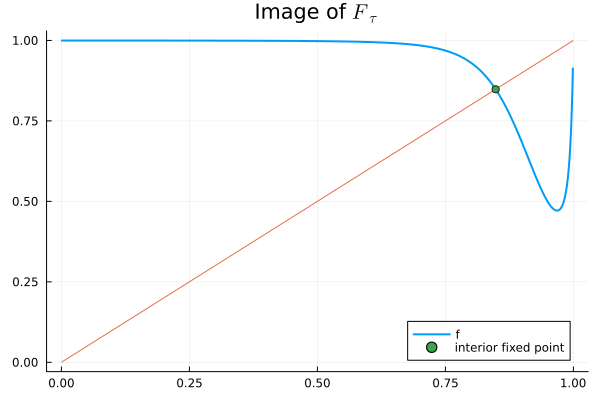

In [3]:
### generate trajectories and map plots ##

zeros_of_f = find_zeros(x -> f(x) - x, 0, 1);

mesh = 0.001;
domain = sort([collect(mesh:mesh:1.0-mesh)..., zeros_of_f[2:end-1]...]);
image = f.(domain);

p1 = plot(domain, image, label = "f", linewidth = 2)
plot!(p1, domain, domain, label = "")
scatter!(p1, zeros_of_f[2:end-1], zeros_of_f[2:end-1], label = "interior fixed point")
title!(p1, "Image of \$F_{\\tau}\$")


Calculating Orbits 100%|█████████████████████████████████| Time: 0:00:02


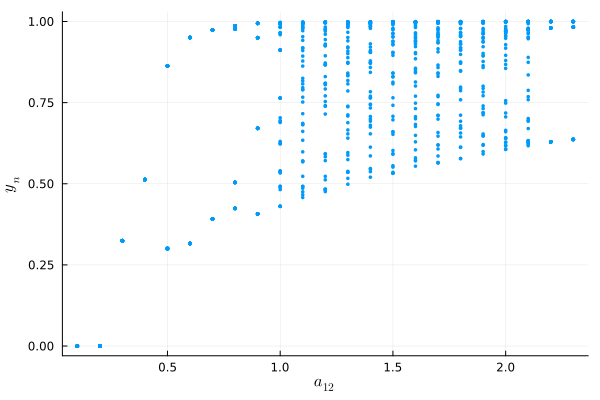

In [4]:
### generate orbit diagram data perturbing parameter a_12 ###

orbit_length = 50
orbit_start_n = 500

parameter_perturbation_index = 4
parameter_perturbation_mesh = 0.1
parameter_perturbation_domain = collect(0.0+parameter_perturbation_mesh:parameter_perturbation_mesh:2*example_params[parameter_perturbation_index])

f_p(p) = x -> forward_map(x, tau, p)

orbit_matrix = zeros((length(parameter_perturbation_domain), 50))

pm = Progress(length(parameter_perturbation_domain), "Calculating Orbits")
for i in eachindex(parameter_perturbation_domain)
    test_parameters = copy(example_params)
    test_parameters[parameter_perturbation_index] = parameter_perturbation_domain[i]
    ff = f_p(test_parameters)
    orbit_vector = zeros(orbit_start_n + orbit_length - 1)
    orbit_vector[1] = 0.5
    for j in eachindex(orbit_vector)[2:end]
        orbit_vector[j] = ff(orbit_vector[j-1])
    end
    orbit_matrix[i, :] = orbit_vector[end - orbit_length + 1:end]
    next!(pm)
end

p2 = scatter(
    parameter_perturbation_domain, 
    orbit_matrix, 
    label = "",
    xlabel = "\$a_{12}\$",
    ylabel = "\$y_n\$",
    color = 1,
    markerstrokewidth = 0,
    markersize = 2
)


In [5]:
### generate Lyapunov Exponent data ###

lyp_exp_list = zeros(length(parameter_perturbation_domain))
chaos_tools_f = glv_chaostools_forward_map(underlying_problem, tau)

pm = Progress(length(lyp_exp_list), "Calculating Lyapunov Exponent: ")
for i in eachindex(parameter_perturbation_domain)
    test_parameters = copy(example_params)
    test_parameters[parameter_perturbation_index] = parameter_perturbation_domain[i]
    ds = DeterministicIteratedMap(chaos_tools_f, [0.5], test_parameters)
    ls = lyapunovspectrum(ds, 3000, show_progress = false)
    lyp_exp_list[i] = ls[1]
    next!(pm)
end


Calculating Lyapunov Exponent: 100%|████████████████████| Time: 0:00:25


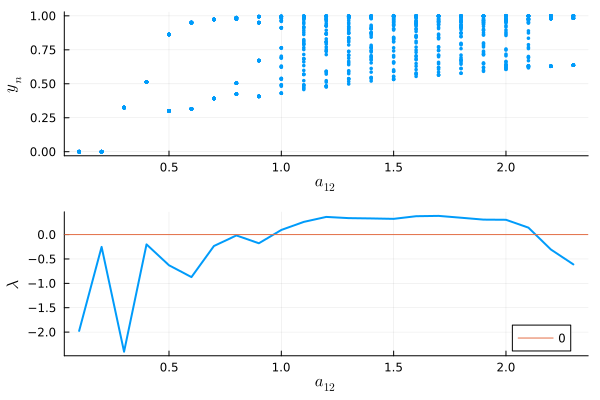

In [6]:
p3 = plot(
    parameter_perturbation_domain, 
    lyp_exp_list, 
    label = "",
    xlabel = "\$a_{12}\$",
    ylabel = "\$\\lambda\$",
    linewidth = 2);
hline!(p3, [0], label = "0");
plot(p2, p3, layout = grid(2, 1))